In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline 

In [3]:
df_index = pd.read_csv("economic_index.csv")
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


For the multi linear regression : 
>> Independent Variable are : interest_rate and Unemployment_rate

>> Dependent Variable : index_price

>> Unnecessay column = year and month

In [4]:
# drop unnecessary columns :
df_index.drop(columns=['Unnamed: 0','year','month'], inplace=True)

In [5]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [6]:
# check for the null value
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

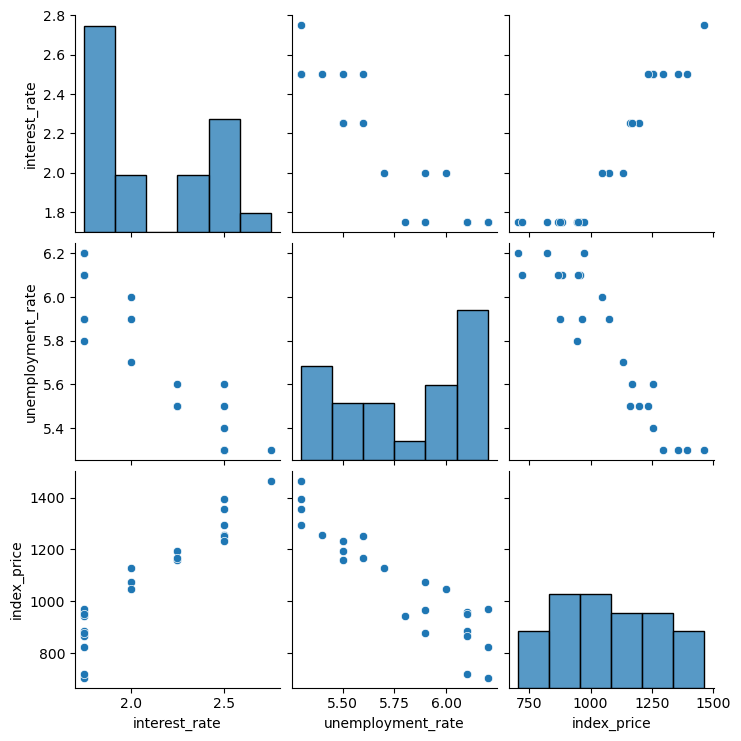

In [7]:
# visualization
import seaborn as sns
sns.pairplot(df_index)


In [ ]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


>> There is negative correlation b/w interest rate and unemployment
>> positive b/w interest rate and index_price

Text(0, 0.5, 'unemployment rate')

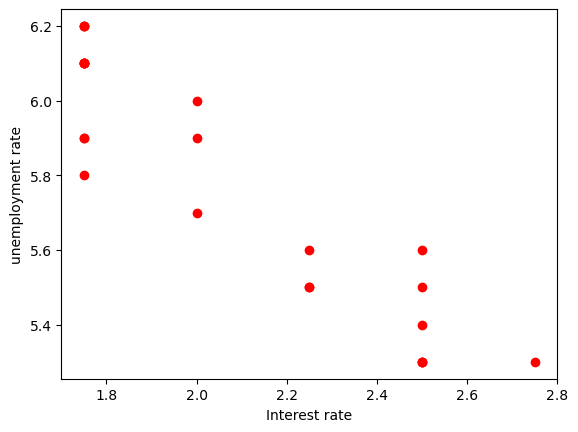

In [10]:
# visualise the data points more closely
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='r')
plt.xlabel("Interest rate")
plt.ylabel("unemployment rate")

In [13]:
# independen t and dependent features
X= df_index.iloc[:,:-1]
y= df_index.iloc[:,-1]

In [15]:
X.head()
y.head()


0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [ ]:
# Train-test split

In [16]:
from sklearn.model_selection import train_test_split

In [24]:
X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.25, random_state=42)

sns.regplot() uses scipy.stats.linregress or statsmodels.OLS internally to compute the regression line.

>> regplot() generates the regression line

<Axes: xlabel='interest_rate', ylabel='index_price'>

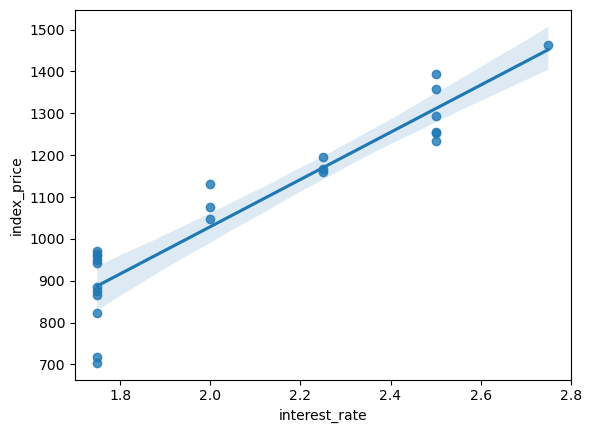

In [18]:
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

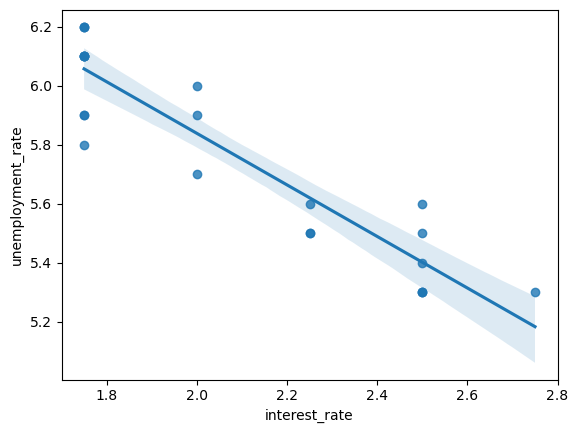

In [20]:
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])


In [21]:
from sklearn .preprocessing import StandardScaler


In [25]:
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.fit_transform(X_test)


In [26]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
regression= LinearRegression()

In [29]:
regression.fit(X_train,y_train)

LinearRegression()

In [30]:
from sklearn.model_selection import cross_val_score


In [33]:
validation_score =cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error', cv=3)


In [34]:
np.mean(validation_score)


-5914.8281801623925

In [36]:
## prediction
y_pred = regression.predict(X_test)
y_pred


array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [ ]:
# Performance Metrics 
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

8108.567426306604
73.80444932337097
90.04758423359621


In [38]:
from sklearn.metrics import r2_score

In [40]:
score = r2_score(y_test,y_pred)
print(score)

0.7591371539010257


In [43]:
# display adjusted R-squared
print(1- (1-score)*(len(y_test)-1)/(len(y_test)- X_test.shape[1]-1))

0.5985619231683761


In [ ]:
# Assumptions

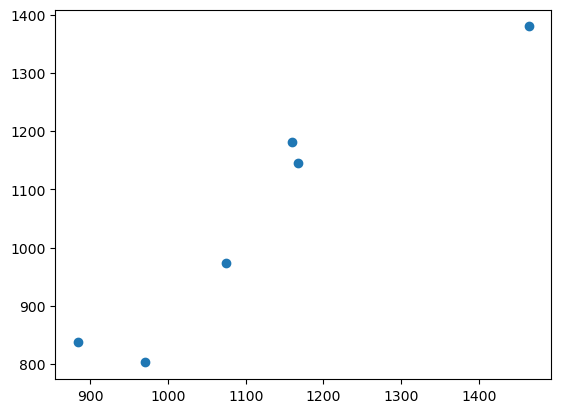

In [44]:
plt.scatter(y_test, y_pred)


In [46]:
residuals= y_test-y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


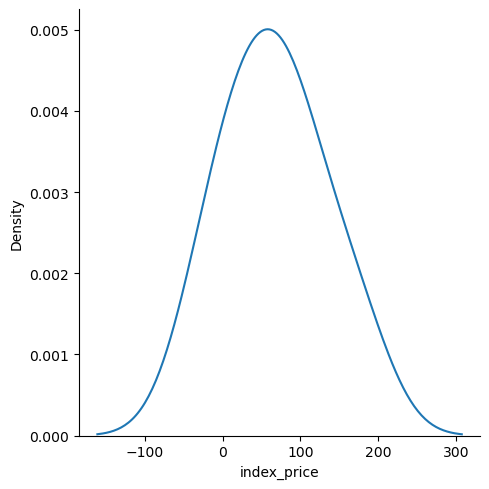

In [47]:
sns.displot(residuals, kind= 'kde')


>> this graph show, the model, I have created is good

In [ ]:
## scatter plot with respect to predictions and residuals

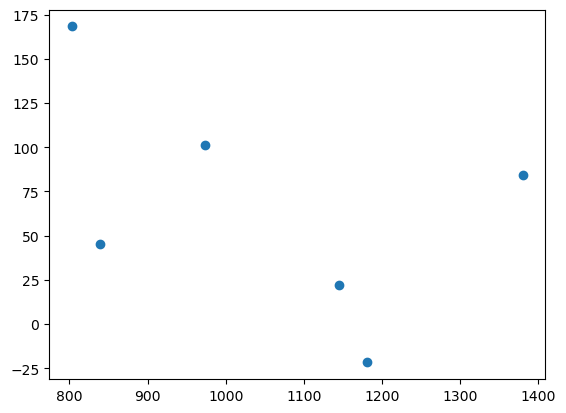

In [48]:
plt.scatter(y_pred,residuals)


>> The data is distributed everywhere, means it doesn't follow any pattern --> hence it's correct

>> If it follow some kind of pattern then something is wrong


>> Calculate the OLS : Ordinary Least Square

In [50]:
import statsmodels.api as sm
model= sm.OLS(y_train, X_train).fit()

In [51]:
model.summary()

/Users/akashdeep/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Thu, 10 Jul 2025   Prob (F-statistic):                       0.754
Time:                        22:31:39   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [53]:
print(regression.coef_)


[  88.27275507 -116.25716066]
